In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [6]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.cn1 = nn.Conv2d(1, 16, 3, 1)
        self.cn2 = nn.Conv2d(16, 32, 3, 1)
        self.dp1 = nn.Dropout2d(0.10)
        self.dp2 = nn.Dropout2d(0.25)
        self.fc1 = nn.Linear(4608, 64) # 4608 is basically 12 X 12 X 32
        self.fc2 = nn.Linear(64, 10)
 
    def forward(self, x):
        x = self.cn1(x)
        x = F.relu(x)
        x = self.cn2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dp1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dp2(x)
        x = self.fc2(x)
        op = F.log_softmax(x, dim=1)
        return op

In [7]:
train_dataloader = DataLoader(
    datasets.MNIST('../data', train=True, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=32, shuffle=True)    

test_dataloader = DataLoader(
    datasets.MNIST('../data', train=False, download=True,
                   transform=transforms.Compose([
                       transforms.ToTensor(),
                       transforms.Normalize((0.1307,), (0.3081,))
                   ])),
    batch_size=500, shuffle=False)

In [8]:
data, target = next(iter(train_dataloader))

data.shape, target.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [9]:
def train(model, device, train_loader, optim, epoch):
    model.train()
    for b_i, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optim.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)
        loss.backward()
        optim.step()
        if b_i % 100 == 0:
            print(f'Train Epoch: {epoch} [{b_i * len(data)}/{len(train_loader.dataset)}'
                  f'({100. * b_i / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')

In [10]:
def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {correct}/{len(test_loader.dataset)}'
          f'({100. * correct / len(test_loader.dataset):.0f}%)\n')

In [11]:
torch.manual_seed(0)
device = torch.device("cpu")

model = ConvNet()
optimizer = optim.Adadelta(model.parameters(), lr=0.5)


In [13]:
for epoch in range(1, 3):
    train(model, device, train_dataloader, optimizer, epoch)
    test(model, device, test_dataloader)

/home/istiaqfuad/Desktop/learning_pytorch/.venv/lib/python3.13/site-packages/torch/nn/functional.py:1535: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  warnings.warn(warn_msg)


Train Epoch: 1 [0/60000(0%)]	Loss: 2.295788
Train Epoch: 1 [3200/60000(5%)]	Loss: 0.259480
Train Epoch: 1 [6400/60000(11%)]	Loss: 0.205654
Train Epoch: 1 [9600/60000(16%)]	Loss: 0.258150
Train Epoch: 1 [12800/60000(21%)]	Loss: 0.207062
Train Epoch: 1 [16000/60000(27%)]	Loss: 0.048056
Train Epoch: 1 [19200/60000(32%)]	Loss: 0.103407
Train Epoch: 1 [22400/60000(37%)]	Loss: 0.138387
Train Epoch: 1 [25600/60000(43%)]	Loss: 0.315546
Train Epoch: 1 [28800/60000(48%)]	Loss: 0.128868
Train Epoch: 1 [32000/60000(53%)]	Loss: 0.119305
Train Epoch: 1 [35200/60000(59%)]	Loss: 0.008688
Train Epoch: 1 [38400/60000(64%)]	Loss: 0.027396
Train Epoch: 1 [41600/60000(69%)]	Loss: 0.035199
Train Epoch: 1 [44800/60000(75%)]	Loss: 0.005852
Train Epoch: 1 [48000/60000(80%)]	Loss: 0.006224
Train Epoch: 1 [51200/60000(85%)]	Loss: 0.188227
Train Epoch: 1 [54400/60000(91%)]	Loss: 0.001830
Train Epoch: 1 [57600/60000(96%)]	Loss: 0.007393

Test set: Average loss: 0.0499, Accuracy: 9823/10000(98%)

Train Epoch: 2 [0/

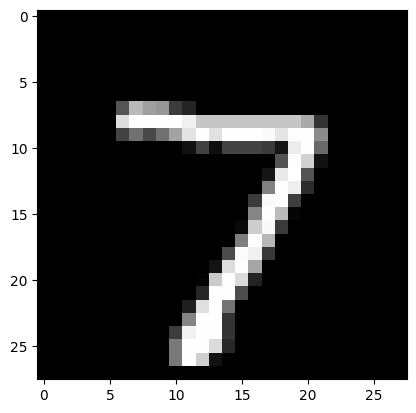

In [20]:
test_samples = enumerate(test_dataloader)

b_i, (sample_data, sample_targets) = next(test_samples)

plt.imshow(sample_data[0][0], cmap='gray', interpolation='none')
plt.show()

# sample_data[0][0].shape

In [22]:
print(f"Model prediction is : {model(sample_data).data.max(1)[1][0]}")
print(f"Ground truth is : {sample_targets[0]}")

Model prediction is : 7
Ground truth is : 7
